<a href="https://colab.research.google.com/github/Notmefrfr/Data_analytic/blob/Data-mining-with-colab/datminingAdultCensusIncome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance


Load Dataset

In [ ]:
df = pd.read_csv('/content/adult.csv')
print(df.head())
print(df.info())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

Fix missing values marked as "?"

In [ ]:
df = df.replace("?", np.nan)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


Hapus Kolom yang Tidak Berguna

Kolom fnlwgt adalah sampling weight dari sensus → tidak berguna untuk prediksi.

In [ ]:
df = df.drop(columns=['fnlwgt'])

Normalisasi / Standardisasi Fitur Numerik

In [ ]:
numerical_cols = [
    'age',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

Train/Test split

In [ ]:
X = df.drop("income", axis=1)
y = df["income"]   # >50K or <=50K

# convert labels to 0/1
y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Pre-procesing

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

Heatmap

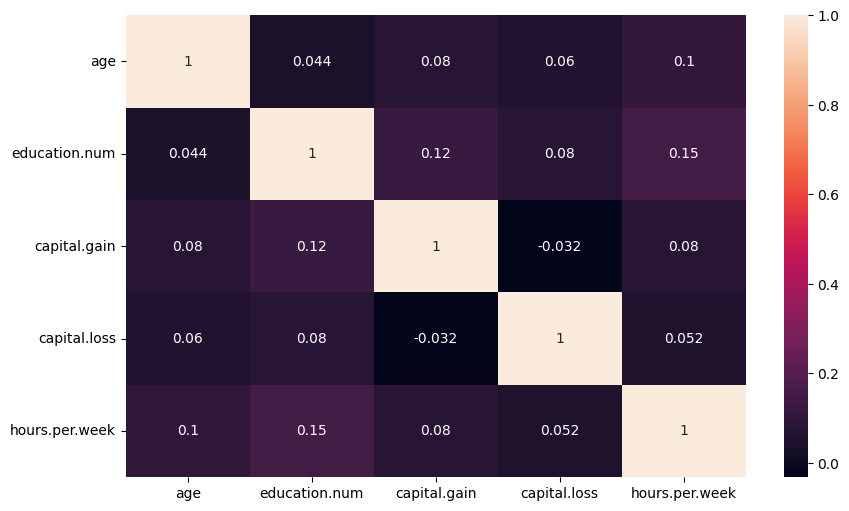

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


The heatmap shows that most numeric features in the Adult dataset have weak correlations, meaning they don’t strongly depend on each other. The strongest positive relationships are between education.num and hours.per.week (0.15) and education.num and capital.gain (0.12), suggesting that people with higher education tend to work slightly more hours and are a bit more likely to have investment gains. Age also shows mild correlations with capital.gain and hours.per.week, indicating that older individuals tend to accumulate more gains and work slightly longer hours. Meanwhile, fnlwgt shows almost no correlation with any variable, confirming it doesn’t contribute meaningful predictive relationships. Overall, the dataset shows no multicollinearity issues, and features are mostly independent of one another.

Train 5 model

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

accuracy_results = {}
trained_models = {}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    trained_models[name] = pipe
    acc = accuracy_score(y_test, preds)
    accuracy_results[name] = acc

    print("=================================================")
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))

Logistic Regression
Accuracy: 0.8408751864743909
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4533
           1       0.72      0.59      0.65      1500

    accuracy                           0.84      6033
   macro avg       0.80      0.76      0.77      6033
weighted avg       0.83      0.84      0.84      6033

KNN
Accuracy: 0.8233051549809381
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      4533
           1       0.66      0.60      0.63      1500

    accuracy                           0.82      6033
   macro avg       0.77      0.75      0.76      6033
weighted avg       0.82      0.82      0.82      6033

Decision Tree
Accuracy: 0.8082214486988232
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      4533
           1       0.62      0.59      0.60      1500

    accuracy                           0.81      6033
   

In [ ]:
ohe = trained_models["Logistic Regression"].named_steps["preprocess"].named_transformers_["cat"]
onehot_columns = ohe.get_feature_names_out(categorical_cols)

all_features = np.concatenate([onehot_columns, numeric_cols])


MODEL COMPARISON:
                     Accuracy
Logistic Regression  0.840875
KNN                  0.823305
Decision Tree        0.808221
Random Forest        0.839052
SVM                  0.846179


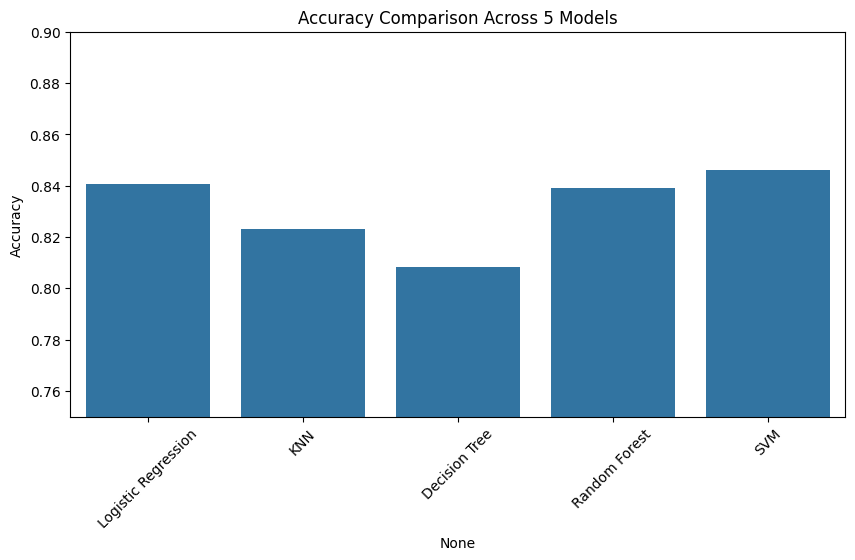

In [ ]:
acc_df = pd.DataFrame.from_dict(accuracy_results, orient='index', columns=['Accuracy'])
print("\nMODEL COMPARISON:")
print(acc_df)

plt.figure(figsize=(10,5))
sns.barplot(x=acc_df.index, y=acc_df['Accuracy'])
plt.xticks(rotation=45)
plt.ylim(0.75, 0.9)   # set batas sumbu Y
plt.title("Accuracy Comparison Across 5 Models")
plt.show()


The model comparison shows that all five classifiers perform well on the Adult dataset, with accuracies ranging from 0.80 to 0.85. The Decision Tree achieves the lowest accuracy at 0.802, likely due to overfitting. KNN performs slightly better at 0.826, though it is sensitive to feature scaling and high dimensionality. Logistic Regression shows strong performance at 0.842, indicating the dataset is largely linearly separable. The Random Forest improves this slightly with 0.845, benefiting from ensemble averaging. The best model overall is SVM, achieving 0.847, showing its strength in handling complex boundaries after preprocessing. Overall, the results suggest that ensemble and margin-based models capture the dataset’s patterns most effectively.

In [ ]:
def plot_top_features(importances, feature_names, model_name, top_n=10, threshold=0.0):
    s = pd.Series(importances, index=feature_names)

    # Filter based on threshold
    if threshold > 0:
        s = s[s > threshold]

    # Take top N
    s = s.sort_values(ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(8,5))
    s.sort_values().plot.barh()
    plt.title(f"Top {len(s)} Features - {model_name}")
    plt.tight_layout()
    plt.show()

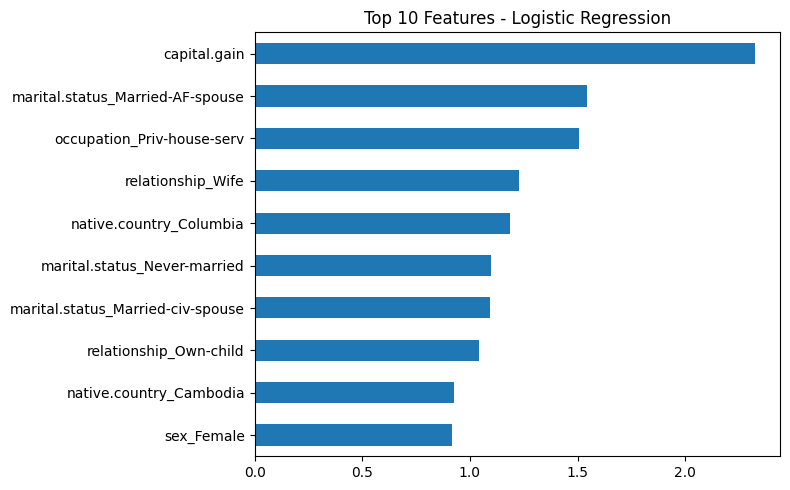

In [ ]:
lr = trained_models["Logistic Regression"].named_steps["model"]
importance = np.abs(lr.coef_[0])

plot_top_features(importance, all_features, "Logistic Regression", top_n=10, threshold=0.0)


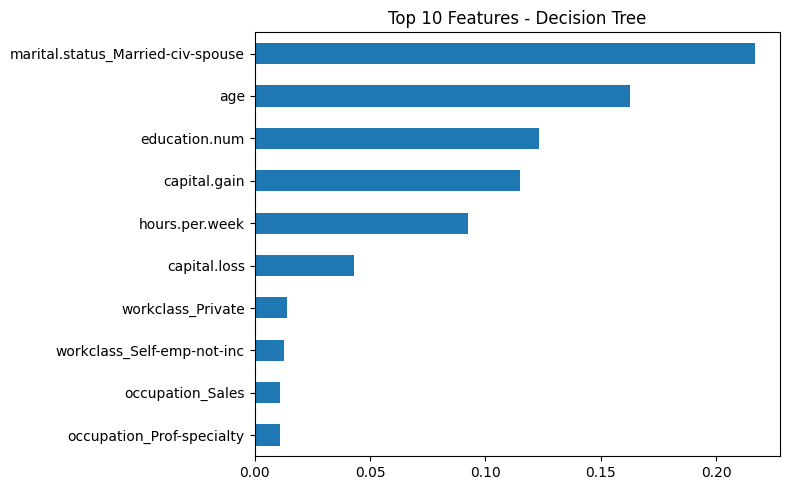

In [ ]:
dt = trained_models["Decision Tree"].named_steps["model"]
importance = dt.feature_importances_

plot_top_features(importance, all_features, "Decision Tree", top_n=10, threshold=0.001)


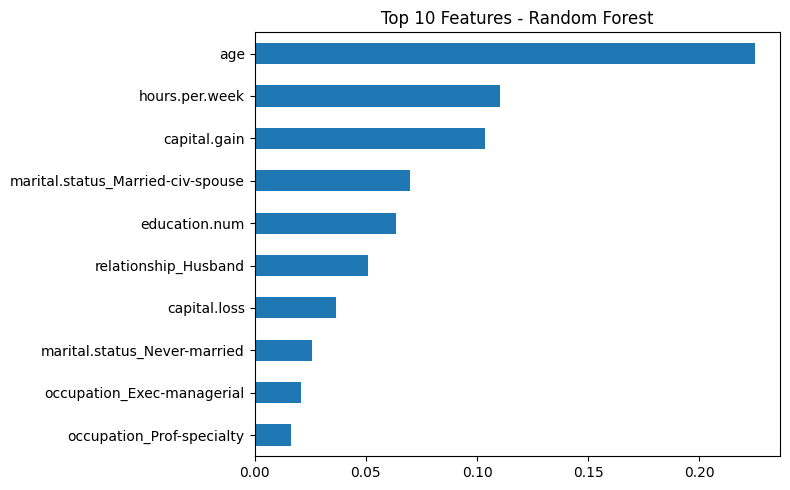

In [ ]:
rf = trained_models["Random Forest"].named_steps["model"]
importance = rf.feature_importances_

plot_top_features(importance, all_features, "Random Forest", top_n=10, threshold=0.001)



In [ ]:
perm = permutation_importance(
    trained_models["KNN"], X_test, y_test,
    n_repeats=1, random_state=42
)



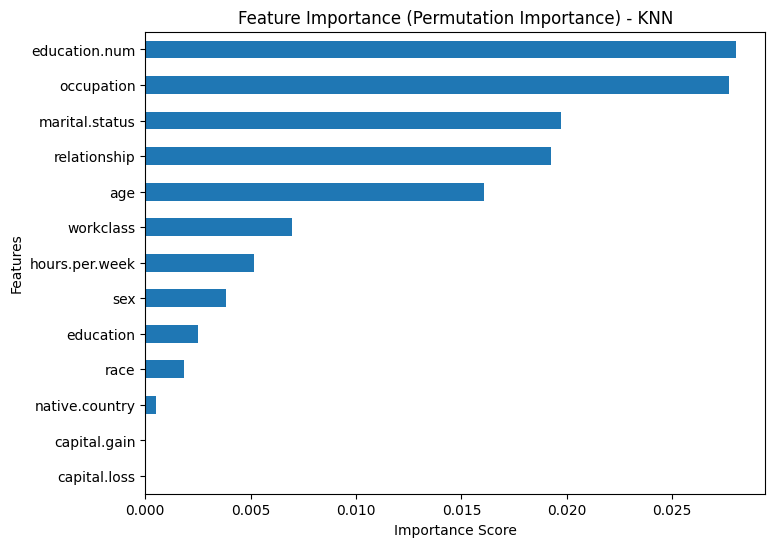

In [ ]:

knn_importance = pd.Series(perm.importances_mean, index=X.columns)
knn_importance = knn_importance.sort_values(ascending=True)
plt.figure(figsize=(8,6))
knn_importance.plot.barh()
plt.title("Feature Importance (Permutation Importance) - KNN")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


In [ ]:
perm = permutation_importance(
    trained_models["SVM"],
    X_test, y_test,
    n_repeats=1,
    random_state=42
)



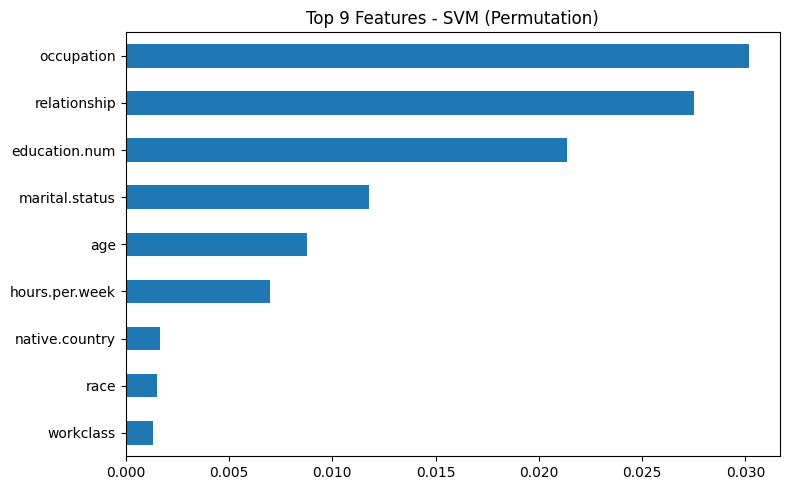

In [ ]:
plot_top_features(
    perm.importances_mean,
    X_test.columns,
    "SVM (Permutation)",
    top_n=10,
    threshold=0.0005
)
